##Contents

0.   Learning Objectives
1.   Tutorial Details
2.   Problem Statement Description
3.   Import Packages
4.   Load and Prepare the Dataset
5.   Peform Exploratory Data Analysis (EDA)
6.   Model Building: Training and Testing
7.   Results and Interpretation
8.   Conclusion
9.   Try it yourself excercise
10.  Summary

0. Learning Objectives

*   Application of  **Random Forest** on a public dataset
*   Utilization of **GridSearchCV** function of sklearn

#1. Tutorial Details

*   **ML Topic(s) Covered**: Random Forest
*   **Problem Statement**: The Car Evaluation Data Set contains information about 1728 car evaluations based on 6 attributes. The  target is to indicate the final recommendation for the car, which can be unacceptable, acceptable, good, or very good.
*   Approximate model training time:10-20 min.

#2. Problem Statement Description

*   **Objective**: To predict the evaluation category of the cars based on various attributes, using Random Forest Classificaiton algorithm.
*   **Data Description**: The dataset contains a total of 1,728 instances and 6 features. Here's a description of the features in the dataset:

    * buying: Buying price of the car (categorical: vhigh, high, med, low)
    * maint: Maintenance price of the car (categorical: vhigh, high, med, low)
    * doors: Number of doors (categorical: 2, 3, 4, 5more)
    * persons: Capacity in terms of persons to carry (categorical: 2, 4, more)
    * lug_boot: Size of luggage boot (categorical: small, med, big)
    * safety: Estimated safety of the car (categorical: low, med, high)


*   More information is available here: https://archive.ics.uci.edu/ml/datasets/Car+Evaluation

# 3. Import Packages

Package versions

*   pandas==1.4.4
*   numpy==1.22.4
*   matplotlib==3.7.1

In [1]:
# Pandas contains functions data manipulation and analysis
import pandas as pd

#Numpy combines high-level mathematical operating capabilites with large, multi-dimensional arrays and matrices
import numpy as np

# Matplotlib is a data visualization library containing functions for static, animated, and interactive 2D and 3D plots
import matplotlib.pyplot as plt

# 4. Load and Prepare the Dataset

In [2]:
#Load the Cars Evaluation Dataset
import requests
# download the data from UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'
response = requests.get(url)

# read the data into a pandas dataframe
df = pd.read_csv(url, header=None, names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class'])

df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


We have 6 features followed by 1 target variable.

In [3]:
#Print the shape of the data
df.shape

(1728, 7)


There are 7 columns (6 features and 1 target variable) and 1728 rows in the imported data.

In [4]:
#Check information about the data including information about the rows and columns, number of non-null values per column, datatype of each column  and total memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


*   Both features and target variables are object (categorical) type. These need to be converted to some numerical value.
*   There is no null value.

Below, let us separate the feature (independent variable) and the target variable (dependent variable) in the data.

In [5]:
features = df.iloc[:, :-1]
predictions = df.iloc[:, -1] #Last column contains the target variable

In [6]:
#Print a fews rows of independent variables
features.head()

,buying,maint,doors,persons,lug_boot,safety
0,vhigh,vhigh,2,2,small,low
1,vhigh,vhigh,2,2,small,med
2,vhigh,vhigh,2,2,small,high
3,vhigh,vhigh,2,2,med,low
4,vhigh,vhigh,2,2,med,med


In [7]:
#Print a fews rows of dependent variables
predictions.head()

0    unacc
1    unacc
2    unacc
3    unacc
4    unacc
Name: class, dtype: object

### Handling Categorical Data
Let's convert categorical data to one hot encoded vectors.

### Multicollineariy
Multicollinearity is a common issue in machine learning when dealing with categorical data. Multicollinearity occurs when two or more predictor variables are highly correlated with each other, which can lead to unstable and unreliable model coefficients and may affect the interpretability and generalizability of the model.


Here are some ways to avoid multicollinearity in categorical data:

  1.  **Drop one of the categories**: One of the most common ways to avoid multicollinearity in categorical data is to drop one of the categories from each categorical variable. This can be done manually or using the drop_first=True parameter in the pd.get_dummies() function in pandas.

  2. **Combine categories**: Another way to avoid multicollinearity is to combine categories that are highly correlated with each other. For example, if we have two categories small and medium for a variable size, we can combine them into a single category small/medium to reduce the number of dummy variables.

  3. **Use regularization**: Regularization techniques such as L1 and L2 regularization can also help to reduce multicollinearity in the data by adding a penalty term to the model's cost function. This penalty term encourages the model to select only the most important features and to reduce the impact of correlated features.

  4. **Use dimensionality reduction**: Dimensionality reduction techniques such as factor analysis can also be used to reduce the dimensions of the data and to identifythe most important features that explain most of the variance in the data. These techniques can be especially useful when dealing with high-dimensional categorical data.

Here we will use the *Drop one of the categories* method.


In [8]:
features_cat = pd.get_dummies(features, drop_first=True) #get k-1 dummies out of k categorical levels by removing the first level.
features_cat

,buying_low,buying_med,buying_vhigh,maint_low,maint_med,maint_vhigh,doors_3,doors_4,doors_5more,persons_4,persons_more,lug_boot_med,lug_boot_small,safety_low,safety_med
0,False,False,True,False,False,True,False,False,False,False,False,False,True,True,False
1,False,False,True,False,False,True,False,False,False,False,False,False,True,False,True
2,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False
3,False,False,True,False,False,True,False,False,False,False,False,True,False,True,False
4,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1723,True,False,False,True,False,False,False,False,True,False,True,True,False,False,True
1724,True,False,False,True,False,False,False,False,True,False,True,True,False,False,False
1725,True,False,False,True,False,False,False,False,True,False,True,False,False,True,False
1726,True,False,False,True,False,False,False,False,True,False,True,False,False,False,True


Now the number of columns have been increased to 15.

Below, let us divided into the training and testing data.

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features_cat, predictions, test_size=0.2, random_state=0, shuffle=True)
#20% of the total data is kept as test data

# 5.   Peform Exploratory Data Analysis (EDA)

Exploratory data analysis (EDA) is a crucial step in understanding and analyzing any dataset.

Henceforth, all the analysis will be performed on the train dataset only. Assume that we do not possess the test data.

In [10]:
Train_data = pd.concat([X_train, y_train], axis = 'columns') #Join along the columns
Train_data.head()

,buying_low,buying_med,buying_vhigh,maint_low,maint_med,maint_vhigh,doors_3,doors_4,doors_5more,persons_4,persons_more,lug_boot_med,lug_boot_small,safety_low,safety_med,class
1649,True,False,False,True,False,False,True,False,False,False,False,False,True,False,False,unacc
1465,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,unacc
361,False,False,True,True,False,False,True,False,False,True,False,False,True,False,True,unacc
315,False,False,True,False,True,False,False,False,True,False,True,False,True,True,False,unacc
1372,True,False,False,False,False,True,False,True,False,False,True,True,False,False,True,acc


In [11]:
#Print summary statistics
Train_data.describe()

,buying_low,buying_med,buying_vhigh,maint_low,maint_med,maint_vhigh,doors_3,doors_4,doors_5more,persons_4,persons_more,lug_boot_med,lug_boot_small,safety_low,safety_med,class
count,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382
unique,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,4
top,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,unacc
freq,1037,1041,1035,1021,1047,1051,1045,1029,1032,927,920,916,923,912,933,970


Since all the features are categorical. We cannot interpret anything significant from the above results.

### Correlation Analysis

In [12]:
#Perform correlation analysis between numerical features
corr_mat = Train_data.corr(method ='pearson', numeric_only=True) #Pearson correlation is used
corr_mat

,buying_low,buying_med,buying_vhigh,maint_low,maint_med,maint_vhigh,doors_3,doors_4,doors_5more,persons_4,persons_more,lug_boot_med,lug_boot_small,safety_low,safety_med
buying_low,1.000000,-0.330120,-0.333976,-0.015677,0.013152,-0.002469,0.011182,-0.015803,0.006254,-0.005640,-0.011812,-0.011781,0.001477,-0.004694,0.003257
buying_med,-0.330120,1.000000,-0.331395,-0.011747,-0.002582,0.013087,-0.012323,-0.004236,-0.005250,-0.004530,0.010689,-0.014140,0.016908,0.014279,-0.013575
buying_vhigh,-0.333976,-0.331395,1.000000,0.016554,-0.008230,0.003483,0.001493,0.005230,0.000461,0.002685,0.017681,0.007039,-0.004422,-0.000036,0.000936
maint_low,-0.015677,-0.011747,0.016554,1.000000,-0.336349,-0.333698,0.015230,-0.023452,0.002176,-0.006495,0.011587,-0.006015,-0.010135,-0.023543,0.009546
maint_med,0.013152,-0.002582,-0.008230,-0.336349,1.000000,-0.317440,-0.002712,0.009416,0.000618,-0.004646,0.014353,0.025146,-0.008112,-0.006876,-0.010234
maint_vhigh,-0.002469,0.013087,0.003483,-0.333698,-0.317440,1.000000,-0.006768,0.005652,-0.014923,0.003694,-0.005940,-0.012949,0.018236,0.026596,-0.016432
doors_3,0.011182,-0.012323,0.001493,0.015230,-0.002712,-0.006768,1.000000,-0.332611,-0.330713,-0.003412,0.019080,0.019127,-0.003316,0.019175,-0.012552
doors_4,-0.015803,-0.004236,0.005230,-0.023452,0.009416,0.005652,-0.332611,1.000000,-0.341094,-0.000774,-0.010577,-0.000102,0.002674,-0.024694,0.011738
doors_5more,0.006254,-0.005250,0.000461,0.002176,0.000618,-0.014923,-0.330713,-0.341094,1.000000,-0.004361,-0.000015,-0.000061,-0.014996,-0.003619,0.008129
persons_4,-0.005640,-0.004530,0.002685,-0.006495,-0.004646,0.003694,-0.003412,-0.000774,-0.004361,1.000000,-0.496470,-0.020919,0.029038,0.010597,0.013724


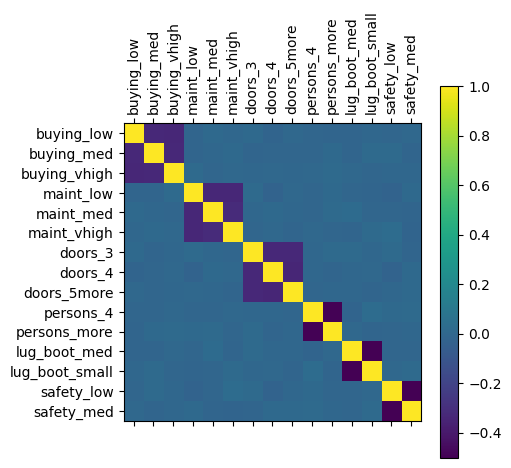

In [13]:
# Visualize the correlation matrix
plt.matshow(corr_mat)
plt.xticks(range(len(corr_mat.columns)), corr_mat.columns, rotation=90)
plt.yticks(range(len(corr_mat.columns)), corr_mat.columns)
plt.colorbar()
plt.show()

We observe that the entire data is nearly uncorrelated. No feature selection is possible based on the correlation matrix.

# 6.   Model Building: Training and Testing

Let us define a Decision Tree model to perform the given classification task.

In [14]:
#Import Random Forest Classifier class
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(criterion='entropy',random_state=42) #Define an object of Decision Tree Classifier class

model.fit(X_train, y_train) #Training the model on train data
y_pred_train = model.predict(X_train) #Make predictions on the training set
y_pred = model.predict(X_test) #Make predictions on the testing set

# 7.   Result and Interpretation

In [15]:
from sklearn.metrics import f1_score, confusion_matrix

# Print the evaluation metrics on train data
F1_train = f1_score(y_train, y_pred_train, average='weighted')
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Evaluation metrics: Train Data")
print("Train F1 score: ", np.round(F1_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Print the evaluation metrics on train data
F1 = f1_score(y_test, y_pred, average='weighted')
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test F1 score: ", np.round(F1, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Evaluation metrics: Train Data
Train F1 score:  1.0
Train confusion matrix: 
 [[305   0   0   0]
 [  0  52   0   0]
 [  0   0 970   0]
 [  0   0   0  55]]
Test F1 score:  0.882
Test confusion matrix: 
 [[ 60   4  15   0]
 [  8   7   0   2]
 [  6   0 234   0]
 [  4   0   0   6]]


There seems no miss-classifications in the train data. The F1-score on train data is 1. The test data has an F1 score of 0.89. It seems to be a case of **overfitting**.

Let us tune the hyperparameters and see if we can improve the results.

In [16]:
model1 = RandomForestClassifier(criterion='entropy', random_state=42, min_samples_split=12, n_estimators=80, ccp_alpha=0.001)
model1.fit(X_train, y_train) #Training the model on train data
y_pred_train = model1.predict(X_train) #Make predictions on the training set
y_pred = model1.predict(X_test) #Make predictions on the testing set

#Check evaluation metrices

# Print the evaluation metrics on train data
F1_train = f1_score(y_train, y_pred_train, average='weighted')
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Evaluation metrics: Train Data")
print("Train F1 score: ", np.round(F1_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Print the evaluation metrics on train data
F1 = f1_score(y_test, y_pred, average='weighted')
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test F1 score: ", np.round(F1, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Evaluation metrics: Train Data
Train F1 score:  0.922
Train confusion matrix: 
 [[281   0  23   1]
 [ 29  11  10   2]
 [ 12   0 958   0]
 [ 18   0   0  37]]
Test F1 score:  0.831
Test confusion matrix: 
 [[ 55   2  22   0]
 [ 15   0   0   2]
 [  5   0 235   0]
 [  5   0   0   5]]


This looks a much better result. However, can we improve it further?

Let us apply Grid Search & see if the results improve.

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [40, 60, 80, 100, 200, 300, 400, 500],
    'max_depth' : [4, 5, 6, 7, 8, 9, 10, 11, 12],
    'criterion' :['gini', 'entropy']
}

In [18]:
CV_rfc = GridSearchCV(estimator=model, param_grid=param_grid, cv=5)
CV_rfc.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [4, 5, ...], 'n_estimators': [40, 60, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [19]:
CV_rfc.best_params_

{'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 100}

In [20]:
model2 = RandomForestClassifier(random_state=42, criterion='entropy', max_depth= 10, n_estimators=100)
model2.fit(X_train, y_train)
y_pred_train = model2.predict(X_train) #Make predictions on the training set
y_pred = model2.predict(X_test) #Make predictions on the testing set

#Check evaluation metrices

# Print the evaluation metrics on train data
F1_train = f1_score(y_train, y_pred_train, average='weighted')
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Evaluation metrics: Train Data")
print("Train F1 score: ", np.round(F1_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Print the evaluation metrics on train data
F1 = f1_score(y_test, y_pred, average='weighted')
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test F1 score: ", np.round(F1, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Evaluation metrics: Train Data
Train F1 score:  0.996
Train confusion matrix: 
 [[305   0   0   0]
 [  0  51   0   1]
 [  3   0 967   0]
 [  2   0   0  53]]
Test F1 score:  0.875
Test confusion matrix: 
 [[ 60   3  16   0]
 [  9   4   0   4]
 [  5   0 235   0]
 [  3   0   0   7]]


# 8. Conclusion

A random forest classifier has been trained for the car evaluation dataset.

# 9.   Try it yourself excercise


*   **Problem Statement**: Perform Random Forest-based classification to predict whether a rice kernel belongs to Cammeo or Osmancik based on the available information.

*   **Task**: The Rice (Cammeo and Osmancik) Data Set is a multivariate dataset that contains shape features of rice kernels of two different varieties: Cammeo and Osmancik. The dataset was collected by taking high-resolution images of the rice kernels and extracting 16 shape features from them. The goal of the dataset is to classify rice kernels into one of the two varieties based on their shape features.

* The dataset contains 3810 instances. There are 7 features in the dataset, which are as follows:

    * Area: The area of the rice kernel in pixels.
    * Perimeter: The perimeter of the rice kernel in pixels.
    * MajorAxisLength: The length of the major axis of the rice kernel in pixels.
    * MinorAxisLength: The length of the minor axis of the rice kernel in pixels.
    * Eccentricity: The eccentricity of the rice kernel.
    * ConvexArea: The area of the convex hull of the rice kernel in pixels.
    * EquivDiameter: The diameter of a circle with the same area as the rice kernel.
    * Extent: The ratio of the area of the rice kernel to the area of its bounding box.

*  **Source**:  https://archive.ics.uci.edu/ml/datasets/Raisin+Dataset


In [ ]:
import pandas as pd
data = pd.read_excel("https://raw.githubusercontent.com/sachinmotwani20/NPTEL-ML_Datasets/main/Rice_Cammeo_Osmancik.xlsx", sheet_name='Rice')
data.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,Cammeo
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,Cammeo
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,Cammeo
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,Cammeo
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,Cammeo


# 10. Summary

* To apply **Random Forest** on a public dataset
* To apply **Grid Search** for settign hyperparamaeters in the model
